- ## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

- ## Load the Datasets

In [2]:
RAW_GAP10 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_10.csv"
)

RAW_GAP30 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_30.csv"
)

RAW_GAP50 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_50.csv"
)

gap10 = pd.read_csv(RAW_GAP10)
gap30 = pd.read_csv(RAW_GAP30)
gap50 = pd.read_csv(RAW_GAP50)

datasets = {
    "10": gap10,
    "30": gap30,
    "50": gap50
}

- ## Forward Fill Function

In [3]:
def forward_fill(df):
    """
    Forward-fill missing observations using the
    last valid observation (LOCF).
    """

    result = df.copy()

    result["imputed_flux"] = (
        result["corrupted_flux"]
        .ffill()
    )

    return result

- ## Apply Forward Fill

In [4]:
results = {}

for level, df in datasets.items():

    reconstructed = forward_fill(df)

    results[level] = reconstructed

print("Forward fill completed.")

Forward fill completed.


- ## Check Remaining Missing Values

In [5]:
summary = []

for level, df in results.items():

    summary.append({

        "Missing (%)": level,

        "Remaining NaN":
            df["imputed_flux"].isna().sum()

    })

summary = pd.DataFrame(summary)

summary

,Missing (%),Remaining NaN
0,10,0
1,30,0
2,50,0


- ## Visual Comparison

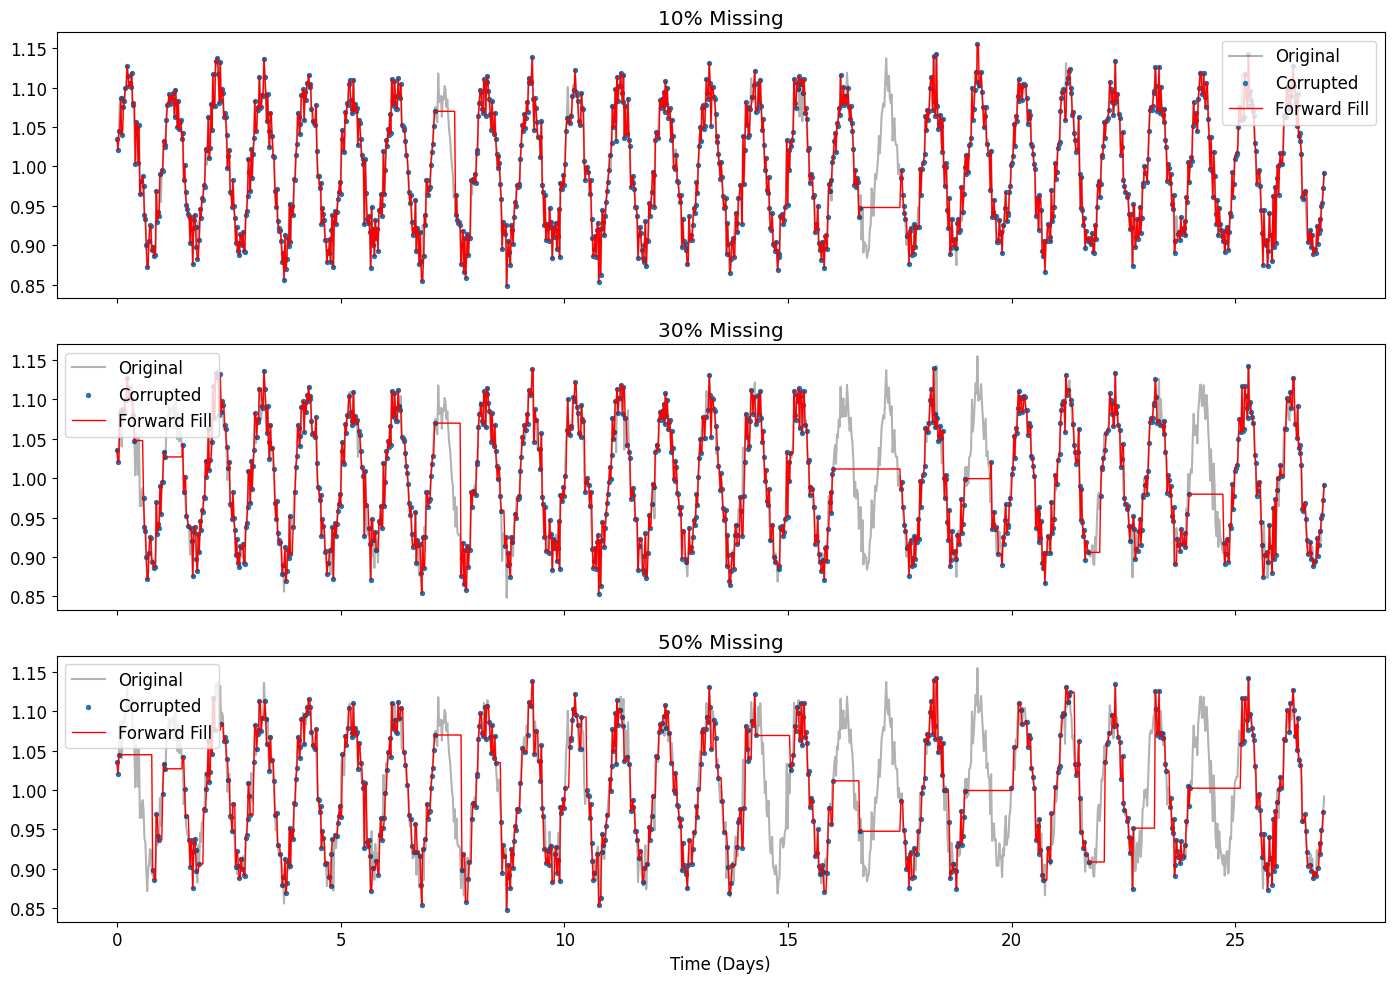

In [6]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        alpha=0.3,
        label="Original"
    )

    ax.scatter(
        df["time"],
        df["corrupted_flux"],
        s=8,
        label="Corrupted"
    )

    ax.plot(
        df["time"],
        df["imputed_flux"],
        color="red",
        linewidth=1,
        label="Forward Fill"
    )

    ax.set_title(
        f"{level}% Missing"
    )

    ax.legend()

plt.xlabel("Time (Days)")
plt.tight_layout()
plt.show()

- ## Imputed Values Only

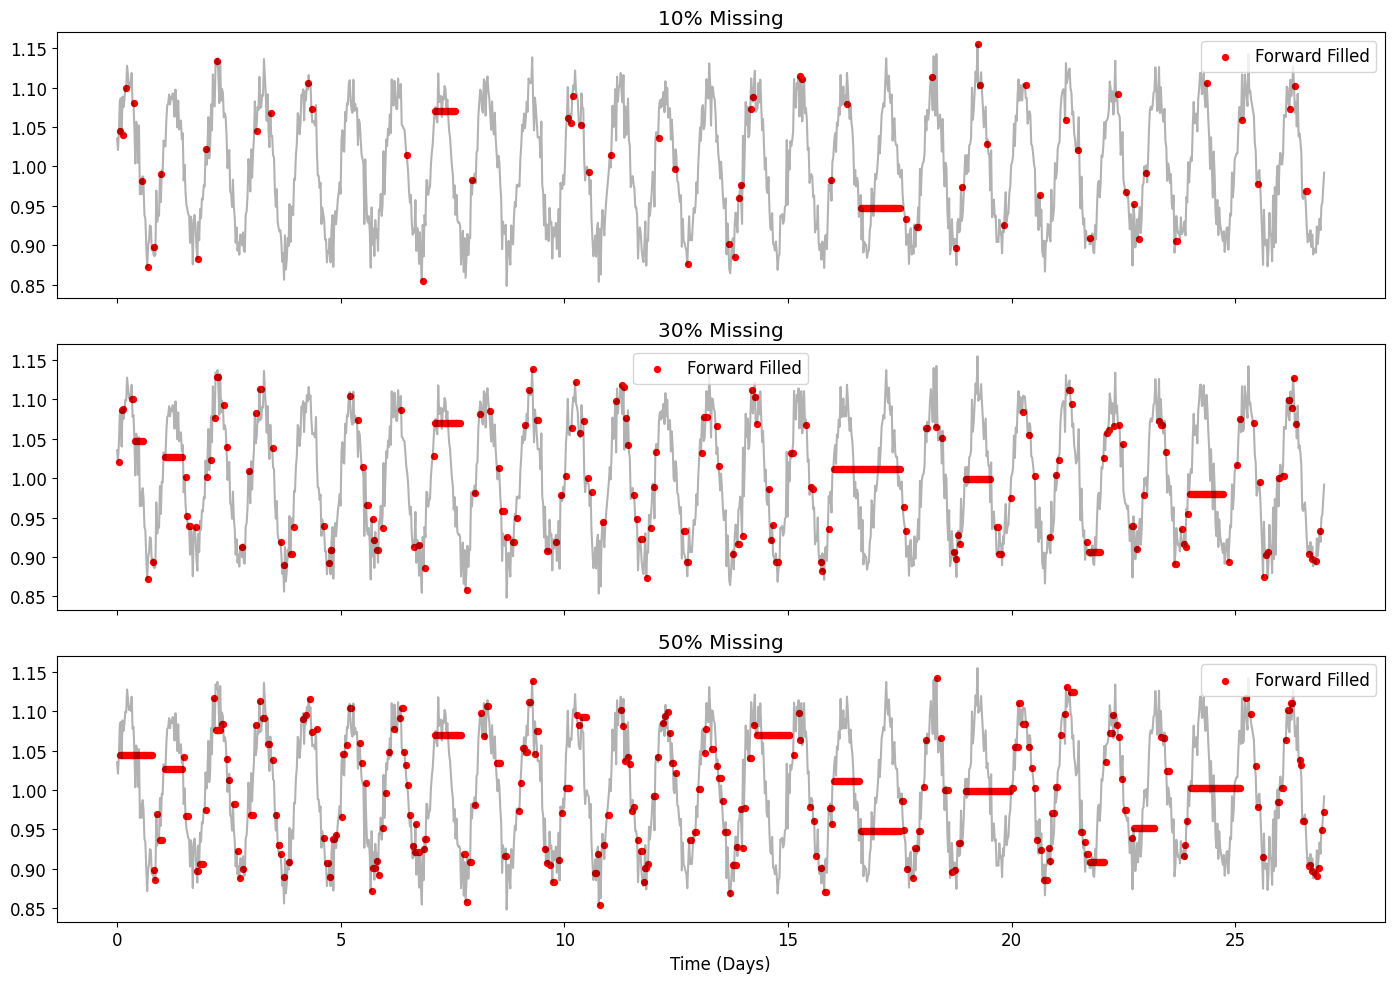

In [7]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    missing = df["mask"] == 0

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        alpha=0.3
    )

    ax.scatter(
        df.loc[missing, "time"],
        df.loc[missing, "imputed_flux"],
        color="red",
        s=18,
        label="Forward Filled"
    )

    ax.legend()

    ax.set_title(
        f"{level}% Missing"
    )

plt.xlabel("Time (Days)")
plt.tight_layout()
plt.show()

- ## Save the Results

In [8]:
OUTPUT_DIR = Path(
    "data/imputed_data/forward_fill"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for level, df in results.items():

    filename = (
        OUTPUT_DIR /
        f"forward_fill_{level}.csv"
    )

    df.to_csv(
        filename,
        index=False
    )

    print(f"Saved: {filename}")

Saved: data/imputed_data/forward_fill/forward_fill_10.csv
Saved: data/imputed_data/forward_fill/forward_fill_30.csv
Saved: data/imputed_data/forward_fill/forward_fill_50.csv
